# Tutorial 16-1: The Policy Gradient – "REINFORCE on CartPole"

**Course:** CSEN 342: Deep Learning  
**Topic:** Policy Gradients, REINFORCE Algorithm, and Monte Carlo Sampling

## Objective
In Q-Learning (Tutorial 39), we learned a value function $Q(s,a)$ and then derived a policy from it (e.g., "pick the max Q"). This is **Value-Based RL**.

Today, we explore **Policy-Based RL**. We will parameterize the policy $\pi_\theta(a|s)$ directly as a neural network and optimize it to maximize expected reward [cite: 5624-5627].

We will implement the **REINFORCE** algorithm (Williams, 1992), also known as Monte Carlo Policy Gradient. 

**The Intuition:**
* Play a full episode.
* If the total reward was good, increase the probability of *every* action we took.
* If the total reward was bad, decrease the probability.

---

## Part 1: The Policy Network

Unlike DQN, which outputs Q-values (scalars), a Policy Network outputs **probabilities**. 
Since CartPole has 2 discrete actions (Left/Right), our output layer will use **Softmax**.

In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.distributions import Categorical

# Config
env_name = "CartPole-v1"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lr = 1e-3

class PolicyNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.dropout = nn.Dropout(p=0.6)
        self.fc2 = nn.Linear(128, action_size)

    def forward(self, x):
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        # Output PROBABILITIES (sum to 1)
        return F.softmax(x, dim=1)

    def act(self, state):
        state_t = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state_t)
        
        # Create a categorical distribution to sample from
        m = Categorical(probs)
        action = m.sample()
        
        # We return the action AND the log_prob (needed for gradient calculation later)
        return action.item(), m.log_prob(action)

env = gym.make(env_name)
policy = PolicyNetwork(env.observation_space.shape[0], env.action_space.n).to(device)
optimizer = optim.Adam(policy.parameters(), lr=lr)

print("Policy Network initialized.")

Policy Network initialized.


---

## Part 2: The Rollout (Monte Carlo)

REINFORCE is an **on-policy** algorithm. We cannot use a Replay Buffer. We must play an episode from start to finish using the *current* policy, collect the data, update the model, and then discard the data.

This function plays one full episode and saves the rewards and log-probabilities.

In [2]:
def play_episode(env, policy):
    saved_log_probs = []
    rewards = []
    
    state, _ = env.reset()
    done = False
    
    while not done:
        action, log_prob = policy.act(state)
        saved_log_probs.append(log_prob)
        
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        rewards.append(reward)
        
    return saved_log_probs, rewards

---

## Part 3: Discounted Returns

The reward $r_t$ is immediate. But an action at $t=0$ might cause a failure at $t=10$. 
We calculate the **Return** $G_t$, which is the sum of discounted future rewards[cite: 5771].

$$ G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \dots $$

In [3]:
def calculate_returns(rewards, gamma=0.99):
    returns = []
    R = 0
    # Calculate backwards: G_t = r_t + gamma * G_{t+1}
    for r in reversed(rewards):
        R = r + gamma * R
        returns.insert(0, R)
        
    returns = torch.tensor(returns, device=device)
    
    # Normalize returns (Critical for training stability!)
    # This acts as a simple baseline to reduce variance (Slide 21)
    returns = (returns - returns.mean()) / (returns.std() + 1e-9)
    return returns

## Part 4: The Training Loop

**The REINFORCE Loss:**
We want to maximize $J(\theta)$, so we minimize the negative log-likelihood weighted by the return.

$$ \text{Loss} = - \sum_{t} (G_t \cdot \log \pi(a_t|s_t)) $$

In [4]:
num_episodes = 500
scores = []

print("Starting Training...")

for i in range(num_episodes):
    # 1. Collect Trajectory
    saved_log_probs, rewards = play_episode(env, policy)
    scores.append(sum(rewards))
    
    # 2. Calculate Returns
    returns = calculate_returns(rewards)
    
    # 3. Calculate Policy Loss
    policy_loss = []
    for log_prob, G in zip(saved_log_probs, returns):
        # Negative because we perform Gradient Descent, but we want to Maximize reward
        policy_loss.append(-log_prob * G)
        
    # Sum loss over the episode
    policy_loss = torch.cat(policy_loss).sum()
    
    # 4. Update Policy
    optimizer.zero_grad()
    policy_loss.backward()
    optimizer.step()
    
    if i % 50 == 0:
        print(f"Episode {i}\tAverage Score: {np.mean(scores[-50:]):.2f}")
        
    if np.mean(scores[-10:]) > 195:
        print(f"Solved at episode {i}!")
        break

print("Training Complete.")

Starting Training...
Episode 0	Average Score: 12.00
Episode 50	Average Score: 27.16
Episode 100	Average Score: 26.44
Episode 150	Average Score: 33.04
Episode 200	Average Score: 43.86
Episode 250	Average Score: 42.68
Episode 300	Average Score: 56.90
Episode 350	Average Score: 65.96
Episode 400	Average Score: 93.12
Episode 450	Average Score: 127.64
Solved at episode 475!
Training Complete.


## Part 5: Visualization

Let's look at the learning curve. You might notice it is "noisy" (high variance). Sometimes the agent forgets how to play and then relearns.

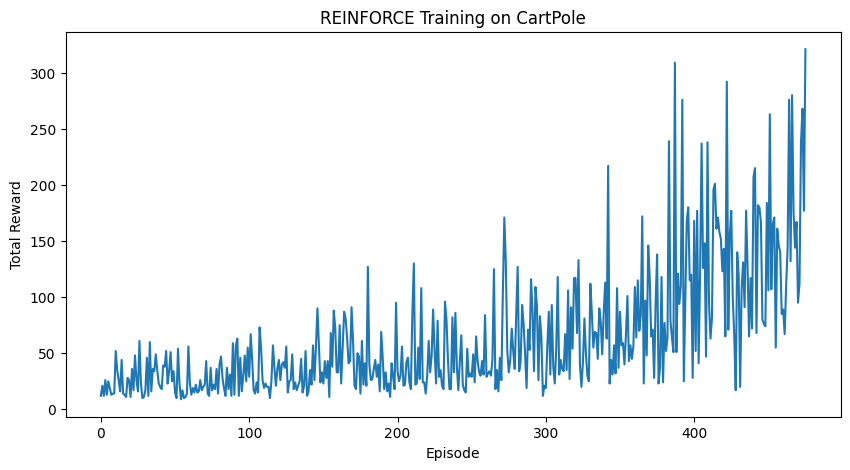

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(scores)
plt.title("REINFORCE Training on CartPole")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

And now we can simulate the environment.

In [7]:
import os
import matplotlib.animation as animation
from IPython.display import HTML

# Create a dummy runtime directory to satisfy the XDG requirement for remote servers
os.environ['XDG_RUNTIME_DIR'] = '/tmp/runtime-root'
if not os.path.exists(os.environ['XDG_RUNTIME_DIR']):
    os.makedirs(os.environ['XDG_RUNTIME_DIR'], exist_ok=True)

# Use 'agg' backend for matplotlib to avoid GUI dependency
import matplotlib
matplotlib.use('Agg')

def visualize_simulation(env_name, model, device, max_steps=500):
    # Re-create environment for rendering
    test_env = gym.make(env_name, render_mode="rgb_array")
    state, _ = test_env.reset()
    frames = []
    done = False
    steps = 0
    
    print("Simulating trained policy...")
    while not done and steps < max_steps:
        # Capture frame
        frames.append(test_env.render())
        
        # Select action using the trained policy (stochastic sampling)
        with torch.no_grad():
            # Use the 'act' method you defined in your PolicyNetwork class
            action, _ = model.act(state)
            
        state, reward, terminated, truncated, _ = test_env.step(action)
        done = terminated or truncated
        steps += 1
    
    test_env.close()
    print(f"Simulation finished after {steps} steps.")
    
    # Create Animation
    fig = plt.figure(figsize=(6, 4))
    plt.axis('off')
    patch = plt.imshow(frames[0])

    def animate(i):
        patch.set_data(frames[i])
        return [patch]

    anim = animation.FuncAnimation(fig, animate, frames=len(frames), interval=50, blit=True)
    plt.close() 
    return HTML(anim.to_jshtml())

# Run the visualization using the 'policy' variable defined in Part 1
visualize_simulation("CartPole-v1", policy, device)

Simulating trained policy...
Simulation finished after 333 steps.


### Conclusion

**Strengths:** REINFORCE is simple and works for stochastic policies.
**Weaknesses:** 
1.  **Sample Inefficient:** We throw away data after every episode.
2.  **High Variance:** If we get a lucky episode with random actions, we reinforce *all* those actions, even the bad ones (Slide 17). 

To fix the variance, we need a **Critic** (Baseline) to tell us if an action was *better than average*, rather than just using the raw return. This leads us to the **Actor-Critic** algorithm in the next tutorial.